# Agricultural Price & Rainfall EDA

Loads WFP Kenya food price data, merges with ERA5/NASA POWER rainfall, and explores price and rainfall patterns.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parents[1]

## Step 0: Prepare ERA5 rainfall data

Converts the raw ERA5 Excel export to a long CSV. Skips if `data/raw/era5_rainfall_long.csv` already exists.

In [2]:
era5_path = PROJECT_ROOT / "data/raw/era5_rainfall_long.csv"

if not era5_path.exists():
    era5 = pd.read_excel(
        PROJECT_ROOT / "data/raw/era5-x0.25_timeseries_pr_timeseries_monthly_1950-2025_mean_historical_era5_x0.25_mean.xlsx"
    )
    era5_long = era5.melt(id_vars=["code", "name"], var_name="year_month", value_name="rainfall_mm")
    era5_long["date"] = pd.to_datetime(era5_long["year_month"], format="%Y-%m")
    era5_long = era5_long.rename(columns={"name": "county"})
    era5_long.to_csv(era5_path, index=False)

## Load WFP price + rainfall data

In [3]:
df = pd.read_csv(PROJECT_ROOT / "data/cleaned/wfp_final_clean.csv", parse_dates=["date"])
df.shape

(27316, 18)

## Fill missing 2026 rainfall from NASA POWER

Rainfall is null for Jan-Aug 2026 (not yet in the ERA5 dataset, and NASA POWER's monthly data only extends through 2025). Fetch 2025 monthly precipitation per region from the NASA POWER API and fill each 2026 null with its 2025 same-month value.

In [4]:
POWER_URL = "https://power.larc.nasa.gov/api/temporal/monthly/point"

centroids = df.groupby("admin1")[["latitude", "longitude"]].mean()


def fetch_power_precip(lat, lon, year):
    params = {
        "parameters": "PRECTOTCORR",
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": year,
        "end": year,
        "format": "JSON",
    }
    resp = requests.get(POWER_URL, params=params, timeout=30)
    resp.raise_for_status()
    return resp.json()["properties"]["parameter"]["PRECTOTCORR"]


power_precip_2025 = {
    admin1: fetch_power_precip(row.latitude, row.longitude, 2025)
    for admin1, row in centroids.iterrows()
}

In [5]:
def fill_rainfall(row):
    ym_2025 = (row["date"] - pd.DateOffset(years=1)).strftime("%Y%m")
    return power_precip_2025[row["admin1"]].get(ym_2025, np.nan)


null_mask = df["rainfall_mm"].isna()
df.loc[null_mask, "rainfall_mm"] = df.loc[null_mask].apply(fill_rainfall, axis=1)
df["rainfall_mm"].isna().sum()

np.int64(0)

In [6]:
df.to_csv(PROJECT_ROOT / "data/cleaned/wfp_final_clean.csv", index=False)

## EDA

### Price distributions

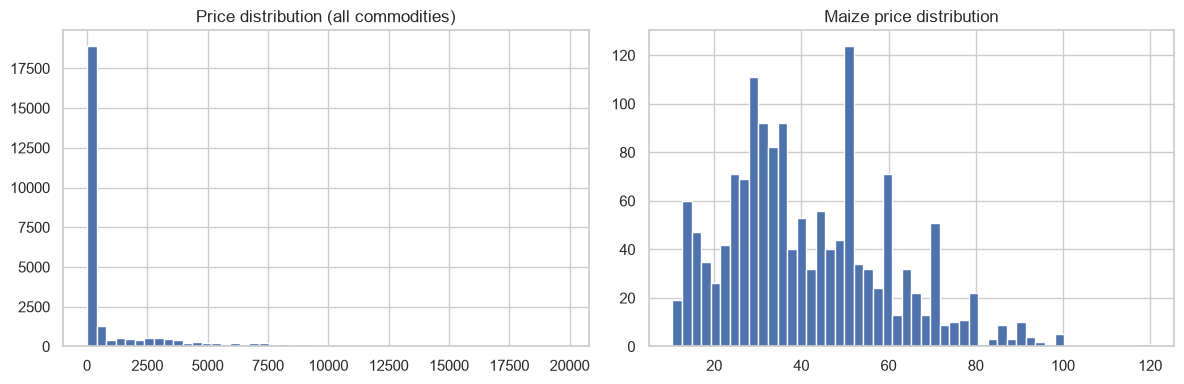

In [7]:
maize = df[df["commodity"] == "Maize"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["price"], bins=50)
axes[0].set_title("Price distribution (all commodities)")
axes[1].hist(maize["price"], bins=50)
axes[1].set_title("Maize price distribution")
plt.tight_layout()
plt.show()

### Maize price trend over time

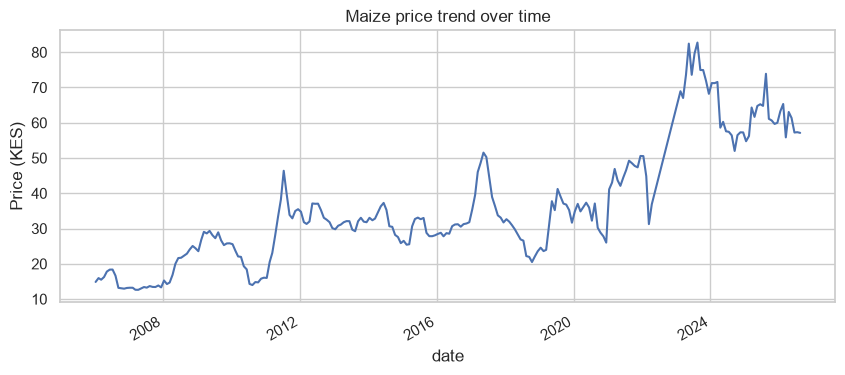

In [8]:
maize_trend = maize.groupby("date")["price"].mean()

plt.figure(figsize=(10, 4))
maize_trend.plot()
plt.title("Maize price trend over time")
plt.ylabel("Price (KES)")
plt.show()

### Regional comparisons

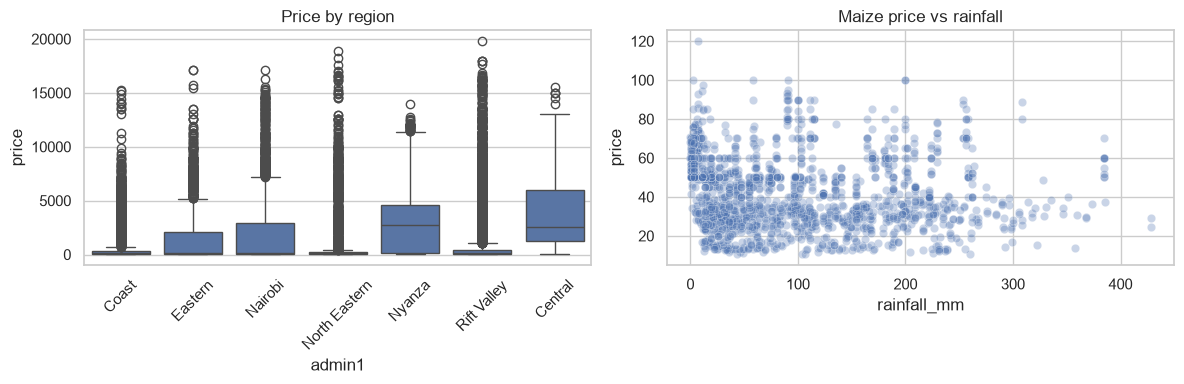

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="admin1", y="price", ax=axes[0])
axes[0].set_title("Price by region")
axes[0].tick_params(axis="x", rotation=45)

sns.scatterplot(data=maize, x="rainfall_mm", y="price", ax=axes[1], alpha=0.3)
axes[1].set_title("Maize price vs rainfall")

plt.tight_layout()
plt.show()